# LangGraph -  Reservation Analytics Agent 

1. **State（状态）**
2. **Node（节点）**
3. **Edge（边）**
4. **Conditional Edge（条件分支）**
5. **START / END**
6. **StateGraph**
7. **compile()**
8. **invoke()**

> **LangGraph = 一个“带状态的流程图执行器”**

它不是“自动帮你思考的 AI”。  
真正的 LLM、RAG、SQL 都在节点里面；LangGraph 主要负责 **流程控制**。

## 0. 一张图先建立直觉

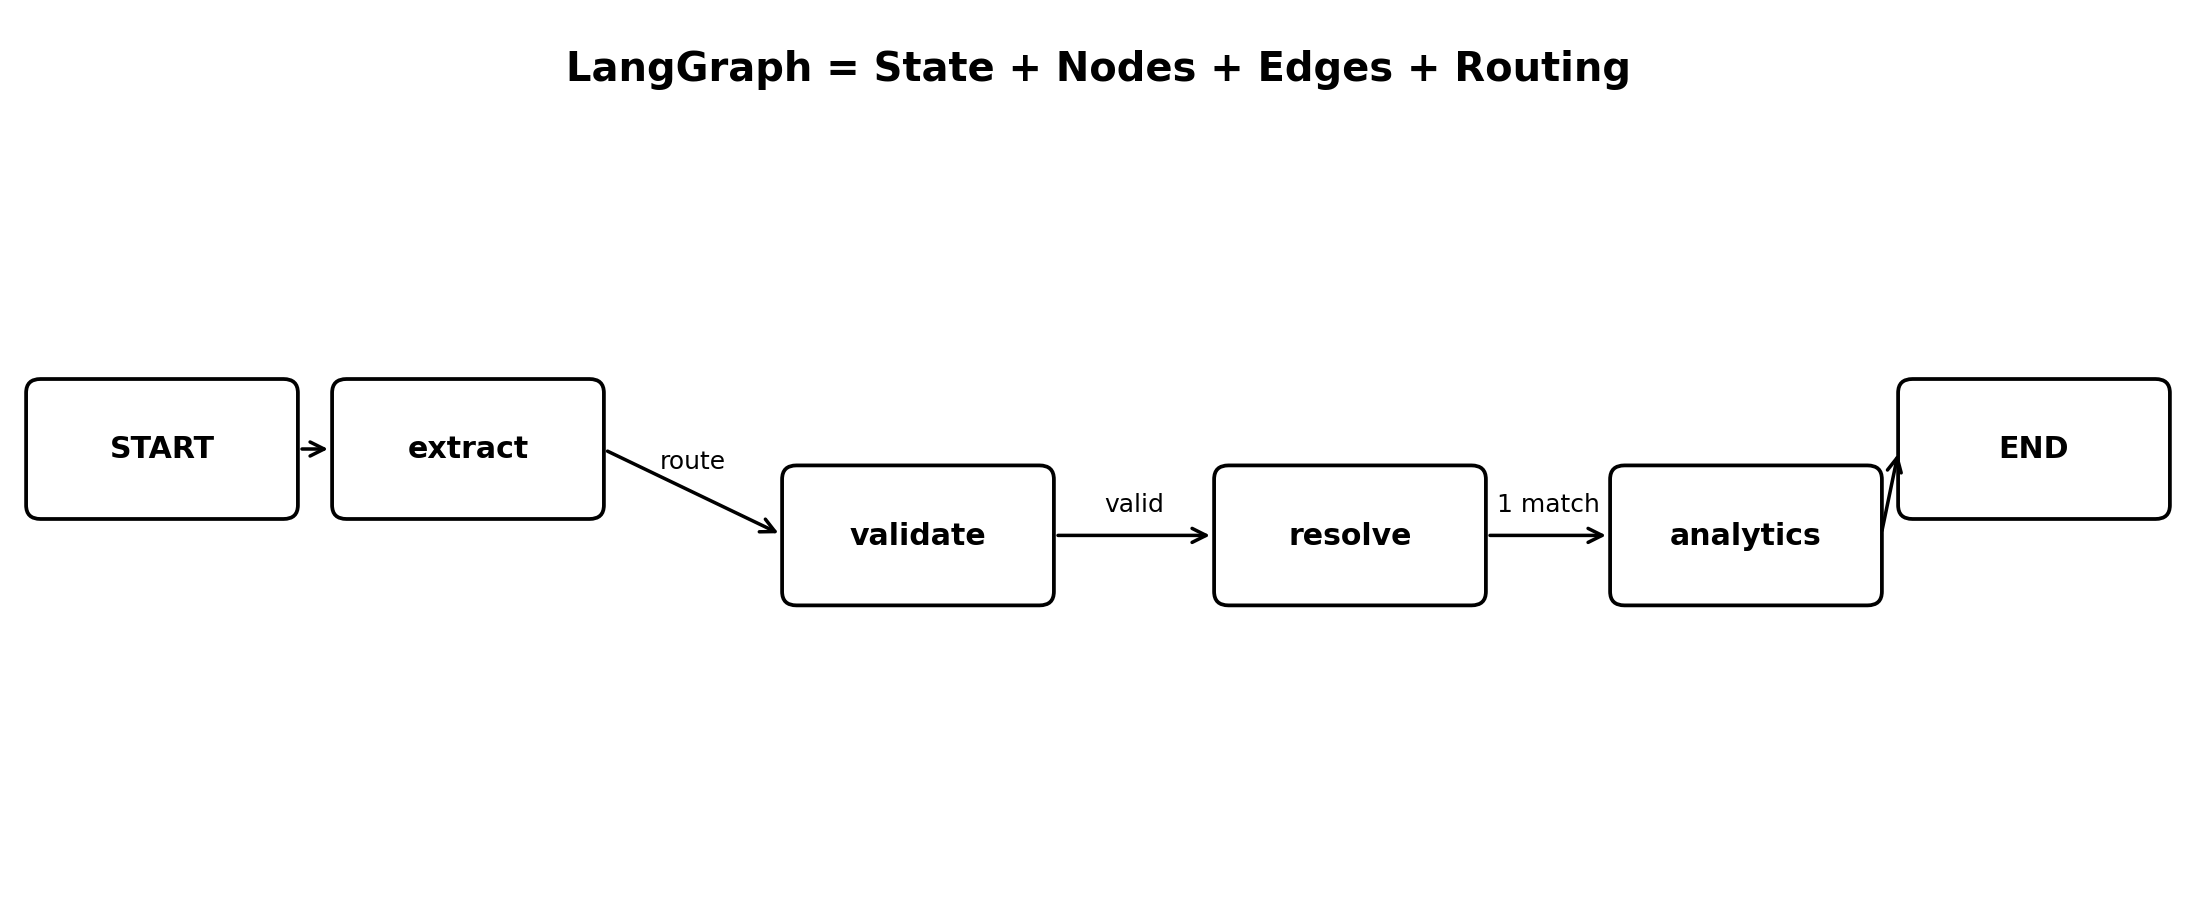

可以把一个 LangGraph 想成：

```text
输入问题
  ↓
extract
  ↓
判断走哪条路
  ↓
validate
  ↓
resolve
  ↓
analytics
  ↓
结束
```

每一个方框就是一个 **Node**。  
箭头就是 **Edge**。  
整张图传递的共享数据就是 **State**。

## 1. State：整个 Graph 共用的一张“工作单”

你项目里：

```python
AgentState
```

可以理解成一张不断被节点补充字段的字典：

```python
{
    "question": "How many reservations for campaign X?",
    "intent": "analytics",
    "metric": "reservation_count",
    "query": {...},
    "resolved_context": {...},
    "status": "answered",
    "answer": "12,345"
}
```

### 最重要的面试解释

> **State carries shared context across nodes. Each node reads the current state and returns updates to the state.**

中文：

> State 是节点之间共享的上下文。每个节点读取当前 state，再返回自己新增或更新的字段。

In [ ]:
from typing import TypedDict

class DemoState(TypedDict, total=False):
    question: str
    intent: str
    status: str
    answer: str

state: DemoState = {
    "question": "How many reservations?"
}

state

### 为什么不用一堆函数参数传来传去？

没有 State 时可能会变成：

```python
extract(question)
validate(question, intent, metric, query)
resolve(question, intent, metric, query, filters)
analytics(question, intent, metric, query, filters, campaign)
```

参数越来越多。

有 State 后：

```python
node(state) -> state update
```

这也是 LangGraph 很重要的价值之一。

## 2. Node：Graph 里的一个处理步骤

Node 本质上就是一个 Python function。

最小例子：

In [ ]:
def extract_node(state: DemoState) -> DemoState:
    question = state["question"]

    if "how many" in question.lower():
        intent = "analytics"
    else:
        intent = "knowledge"

    return {
        **state,
        "intent": intent,
    }

extract_node({"question": "How many reservations?"})

你项目中的：

```python
def extract_node(self, state):
    request = self.extractor.extract(state["question"])
```

这里真正做 NLP / LLM extraction 的是：

```python
self.extractor.extract(...)
```

**LangGraph 本身并没有做 extraction。**

LangGraph 只是说：

> 到了 `extract` 节点，请执行 `extract_node()`。

这点面试很容易被问。

## 3. Edge：决定 Node 的执行顺序

普通 edge：

```python
graph.add_edge("analytics", END)
```

意思就是：

```text
analytics → END
```

没有判断条件。

例如：

```python
graph.add_edge(START, "extract")
```

表示整个 workflow 从 `extract` 开始。

## 4. Conditional Edge：你项目最关键的知识

你的项目：

```python
graph.add_conditional_edges(
    "extract",
    self._after_extract,
    {
        "knowledge": "knowledge",
        "validate": "validate",
    }
)
```

它的思想是：

```text
             → knowledge
extract
             → validate
```

由 `_after_extract(state)` 决定下一步。

In [ ]:
def after_extract(state: DemoState) -> str:
    if state["intent"] == "knowledge":
        return "knowledge"
    return "validate"

print(after_extract({"intent": "knowledge"}))
print(after_extract({"intent": "analytics"}))

### 这一行其实可以拆成三步理解

```python
graph.add_conditional_edges(
    "extract",                 # ① 从哪个 node 出发
    self._after_extract,       # ② 调哪个函数判断路线
    {                          # ③ 判断结果映射到哪个 node
        "knowledge": "knowledge",
        "validate": "validate",
    }
)
```

因此：

```python
_after_extract(state)
```

如果返回：

```python
"knowledge"
```

就走：

```text
extract → knowledge
```

如果返回：

```python
"validate"
```

就走：

```text
extract → validate
```

## 5. START 和 END

```python
from langgraph.graph import START, END
```

它们不是业务节点。

可以理解成两个特殊标记：

```text
START → 第一个节点
最后一个节点 → END
```

项目：

```python
graph.add_edge(START, "extract")
graph.add_edge("knowledge", END)
graph.add_edge("analytics", END)
```

## 6. StateGraph：把 State、Node、Edge 组装起来

最小完整 Graph：

In [ ]:
# 需要先安装：
# pip install langgraph

from typing import TypedDict

class State(TypedDict, total=False):
    question: str
    intent: str
    answer: str

def extract(state: State):
    return {
        "intent": (
            "analytics"
            if "how many" in state["question"].lower()
            else "knowledge"
        )
    }

def knowledge(state: State):
    return {"answer": "This is a business definition."}

def analytics(state: State):
    return {"answer": "Reservation count = 1234"}

def route(state: State):
    return state["intent"]

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

builder.add_node("extract", extract)
builder.add_node("knowledge", knowledge)
builder.add_node("analytics", analytics)

builder.add_edge(START, "extract")

builder.add_conditional_edges(
    "extract",
    route,
    {
        "knowledge": "knowledge",
        "analytics": "analytics",
    },
)

builder.add_edge("knowledge", END)
builder.add_edge("analytics", END)

graph = builder.compile()

## 7. compile()：从“设计图”变成“可执行 workflow”

这句：

```python
graph = builder.compile()
```

可以理解成：

```text
StateGraph builder
      ↓
检查 nodes / edges / routes
      ↓
Compiled Graph
      ↓
可以 invoke()
```

面试表达：

> `compile()` converts the graph definition into an executable graph.

## 8. invoke()：真正执行 Graph

```python
graph.invoke(initial_state)
```

Graph 会从 `START` 自动一路执行。

例如：

In [ ]:
# 如果上面的 langgraph cell 已运行，可以执行：

# graph.invoke({
#     "question": "How many reservations?"
# })

# 预期：
# {
#     "question": "How many reservations?",
#     "intent": "analytics",
#     "answer": "Reservation count = 1234"
# }

## 9. 对照你的 ReservationAgent

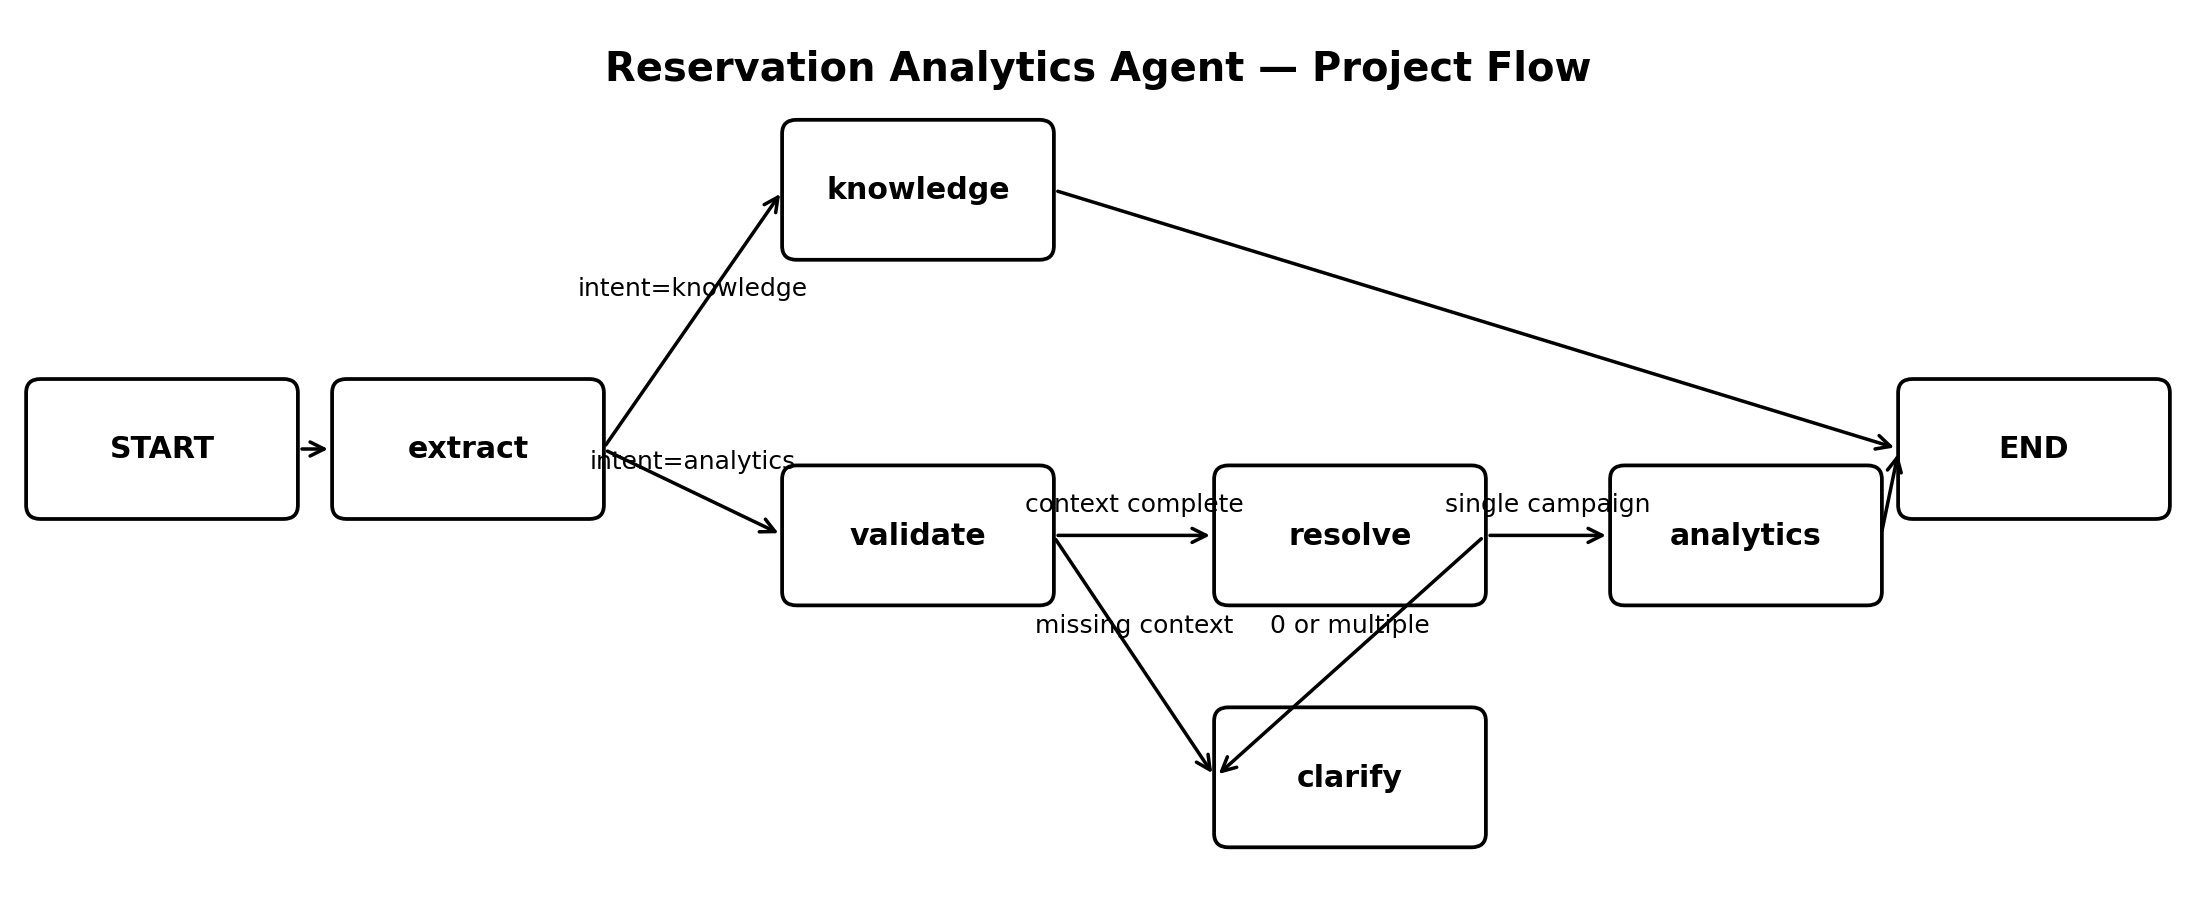

你的完整业务逻辑其实就是这张图。

### 第一段：extract

```python
graph.add_edge(START, "extract")
```

用户：

```text
How many users reserved M Company 17 Pro?
```

进入：

```python
extract_node()
```

Extractor 可能得到：

```python
{
    "intent": "analytics",
    "metric": "reservation_count",
    "query": {
        "campaign_name": "M Company 17 Pro"
    }
}
```

然后：

```python
_after_extract(state)
```

决定：

```text
knowledge
or
validate
```

## 10. 为什么 knowledge 不需要 validate / resolve？

你的设计：

```text
knowledge question
      ↓
RAG
      ↓
answer
```

例如：

```text
What does reservation_count mean?
```

它问的是 **指标定义**，不需要查真实 campaign。

所以：

```text
extract → knowledge → END
```

而：

```text
How many reservations did campaign X have?
```

问的是 **真实业务数字**，才需要：

```text
extract
 ↓
validate
 ↓
resolve
 ↓
analytics
```

这正是你项目最大的 architecture point：

> **Knowledge questions and data questions are separated.**

## 11. validate_node：为什么存在？

你项目：

```python
missing = missing_context(query)

if missing:
    return {
        "status": "clarification",
        "answer": "Please provide ..."
    }
```

例如用户只问：

```text
How many reservations?
```

但是没有：

```text
campaign
market
time range
...
```

系统不应该猜。

所以：

```text
validate
   ├── context complete → resolve
   └── missing context → END
```

这里非常适合作为面试亮点：

> **We explicitly validate required business context before SQL execution to prevent the agent from guessing filters.**

## 12. resolve_node：业务实体消歧

例如用户输入：

```text
M Company 17 campaign
```

数据库里可能有：

```text
C001 — M Company 17 Launch Germany
C002 — M Company 17 Launch France
C003 — M Company 17 Pro Germany
```

Resolver 的作用不是算指标，而是：

> **把自然语言业务上下文解析到唯一 campaign_id。**

你的逻辑：

```text
0 match     → not_found
1 match     → resolved
>1 matches  → clarification
```

这样 analytics 层最后拿到的是明确的：

```python
campaign_id = "C001"
```

而不是让 LLM 自己猜 SQL filter。

## 13. analytics_node：最后才真正查询数据

项目：

```python
self.analytics.run(
    state["metric"],
    campaign,
    state.get("detail_requested", False)
)
```

因此整体安全边界是：

```text
Natural Language
      ↓
Structured Request
      ↓
Validation
      ↓
Campaign Resolution
      ↓
Trusted Analytics Service
      ↓
SQL / Backend
```

这比：

```text
User question → LLM 拼一条任意 SQL
```

更可控。

## 14. 你代码里的三个 routing function

### ① `_after_extract`

```python
return "knowledge" if state["intent"] == "knowledge" else "validate"
```

决定：

```text
知识问题？
├─ Yes → RAG
└─ No  → Analytics workflow
```

### ② `_after_validate`

```python
return "end" if state["status"] == "clarification" else "resolve"
```

决定：

```text
信息够不够？
├─ No  → 停下来让用户补充
└─ Yes → resolve
```

### ③ `_after_resolve`

```python
return "analytics" if state["status"] == "resolved" else "end"
```

决定：

```text
campaign 是否唯一解析成功？
├─ Yes → analytics
└─ No  → 停止
```

这三个函数就是这个项目的 **workflow decision layer**。

## 15. `return {**state, ...}` 到底是什么意思？

你代码大量出现：

```python
return {
    **state,
    "status": "answered",
    "answer": result,
}
```

这不是 LangGraph 特殊语法，是普通 Python dict unpacking。

例如：

In [ ]:
state = {
    "question": "How many reservations?",
    "intent": "analytics"
}

new_state = {
    **state,
    "status": "answered",
    "answer": "1234"
}

new_state

等价于：

```python
new_state = state.copy()
new_state["status"] = "answered"
new_state["answer"] = "1234"
```

所以先把 Python 这点看懂，你读 LangGraph 会容易很多。

## 16. 为什么你的类里还写了一套 fallback？

项目：

```python
try:
    from langgraph.graph import END, START, StateGraph
except ImportError:
    return None
```

如果没有安装 LangGraph：

```python
self._graph = None
```

于是 `invoke()` 手动执行：

```python
extract
→ route
→ validate
→ resolve
→ analytics
```

也就是说：

> **LangGraph 是 orchestration layer，而不是业务逻辑本身。**

你的业务 nodes 即使没有 LangGraph，也能按普通 Python 函数执行。

这是一个很好的 architecture design point：
**business logic is decoupled from orchestration.**

## 17. 面试看这段代码，至少会这 8 个问题

| Question | 你应该怎么答 |
|---|---|
| What is LangGraph? | A stateful workflow/orchestration framework for agent applications. |
| What is State? | Shared context passed and updated across nodes. |
| What is a Node? | A processing step implemented as a Python callable. |
| What is an Edge? | A transition between nodes. |
| Conditional edge? | Runtime routing based on current state. |
| Why compile? | Turn graph definition into an executable graph. |
| Why invoke? | Execute the graph from an initial state. |
| Why use LangGraph here? | Explicit routing, validation, clarification and deterministic workflow control. |

### 项目版回答

> We use LangGraph mainly as the orchestration layer.  
> The graph first extracts a structured request, then routes knowledge questions to RAG.  
> Analytics questions go through context validation and campaign resolution before reaching the analytics service.  
> Conditional edges make clarification and routing explicit instead of letting the LLM decide everything implicitly.

# 18. 你暂时 **不用学** 的 LangGraph 内容

为了这个项目和近期面试，你现在可以先跳过：

- Checkpointer / persistence 深入实现
- Human-in-the-loop API 细节
- Subgraphs
- Streaming
- Send API
- Command API
- Reducers 的高级写法
- Parallel branches
- Multi-agent supervisor
- LangGraph Platform deployment

先把下面这一条主线吃透：

```text
State
 ↓
Node
 ↓
Edge
 ↓
Conditional Edge
 ↓
StateGraph
 ↓
compile
 ↓
invoke
```

然后再重新读 `ReservationAgent`，基本就能读懂 80%。

# 19. 最后练习：自己写一个 20 行 Mini Reservation Graph

要求：

```text
question
  ↓
extract
  ↓
knowledge? ── Yes → answer → END
  ↓ No
validate
  ↓
analytics
  ↓
END
```

你可以自己补完下面代码：

In [ ]:
from typing import TypedDict

class ReservationState(TypedDict, total=False):
    question: str
    intent: str
    metric: str
    status: str
    answer: str


def extract(state: ReservationState):
    # TODO:
    # question 包含 "what is" → knowledge
    # 否则 → analytics
    ...


def knowledge(state: ReservationState):
    return {
        "status": "answered",
        "answer": "reservation_count means ..."
    }


def validate(state: ReservationState):
    # TODO
    ...


def analytics(state: ReservationState):
    # 先不用 SQL，返回 mock number
    return {
        "status": "answered",
        "answer": "Reservation count = 1234"
    }


# TODO:
# 用 StateGraph 把它连接起来

# 20. 学习顺序建议（项目导向）

### 第一轮：30 分钟
只看：

```text
State → Node → Edge → Conditional Edge
```

### 第二轮：30 分钟
自己运行 Mini Graph：

```text
StateGraph → add_node → add_edge
→ add_conditional_edges → compile → invoke
```

### 第三轮：30 分钟
重新打开项目，只追踪：

```text
invoke()
→ extract_node()
→ _after_extract()
→ validate_node()
→ _after_validate()
→ resolve_node()
→ _after_resolve()
→ analytics_node()
```

### 第四轮：30 分钟
准备面试表达：

```text
Why LangGraph?
Why not direct LLM-to-SQL?
Why validation?
Why resolver?
Why separate RAG and analytics?
```

如果这四轮完成，你就不是“会背 LangGraph”，而是已经能够解释 **为什么这个项目要用 LangGraph**。